In [2]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

from pyprojroot import here

In [3]:
exp = pl.read_parquet(here("data/experiment_base_sentiment.parquet"))
posts = pl.read_parquet(here("data/experiment_posts.parquet"))

In [4]:
exp = exp.rename({"id":"subreddit", "subreddit":"id"})
exp = exp.join(posts, on=pl.col("id"), how="inner")

In [5]:
exp = exp.with_columns(pl.col("title").str.slice(offset=0, length=50).alias("title_short"))

In [6]:
exp

subreddit,id,username,username_score,content,label,negative,neutral,positive,prediction,title,post_text,title_short
str,str,str,i64,str,str,f64,f64,f64,str,str,str,str
"""booksuggestions""","""1rwn60r""","""Fresh_Window_6484""",0,"""""The Emperor's Assassin series…","""neutral""",0.010766,0.941441,0.047793,"""neutral""","""Looking for Romantasy Suggesti…","""I don’t usually read romantasy…","""Looking for Romantasy Suggesti…"
"""booksuggestions""","""1rwn60r""","""Fresh_Window_6484""",0,"""'You might like The Darktouche…","""neutral""",0.005267,0.457886,0.536847,"""positive""","""Looking for Romantasy Suggesti…","""I don’t usually read romantasy…","""Looking for Romantasy Suggesti…"
"""AskMen""","""1rvbenb""","""Fresh_Window_6484""",0,"""'Your submission was removed b…","""neutral""",0.494906,0.485624,0.019471,"""negative""","""Advice from older men?""","""[removed]""","""Advice from older men?"""
"""socialskills""","""1rpex9a""","""Fresh_Window_6484""",0,"""'\nThanks for your post at /r/…","""neutral""",0.017095,0.549381,0.433524,"""neutral""","""How do you make small talk fee…","""Even when I try the “ask open …","""How do you make small talk fee…"
"""socialskills""","""1rpex9a""","""Fresh_Window_6484""",0,"""'Be ok with having uncomfortab…","""neutral""",0.185546,0.438182,0.376273,"""neutral""","""How do you make small talk fee…","""Even when I try the “ask open …","""How do you make small talk fee…"
…,…,…,…,…,…,…,…,…,…,…,…,…
"""camping""","""1s0bn9y""","""MAGA_victory24""",1,"""'If I am car camping I bring a…","""conservative""",0.105868,0.705985,0.188147,"""neutral""","""Condensation in the tent""","""Is there a way to avoid so muc…","""Condensation in the tent"""
"""camping""","""1s0bn9y""","""MAGA_victory24""",1,"""'Burn a 12 hour candle inside …","""conservative""",0.163611,0.774304,0.062085,"""neutral""","""Condensation in the tent""","""Is there a way to avoid so muc…","""Condensation in the tent"""
"""camping""","""1s0bn9y""","""MAGA_victory24""",1,"""'Tents vary a lot, so some of …","""conservative""",0.148044,0.794452,0.057504,"""neutral""","""Condensation in the tent""","""Is there a way to avoid so muc…","""Condensation in the tent"""


Text(0.5, 0, 'Experiment Condition')

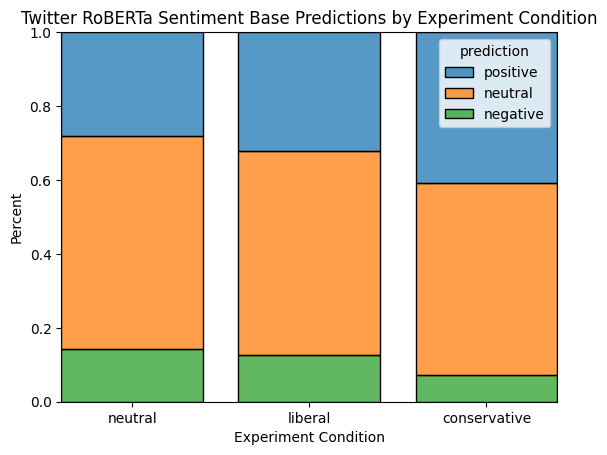

In [7]:
ax = sns.histplot(
    data=exp,
    x="label", hue="prediction",
    hue_order=["positive", "neutral", "negative"],
    multiple="fill", stat="percent",
    discrete=True, shrink=.8
)
ax.set_title("Twitter RoBERTa Sentiment Base Predictions by Experiment Condition")
ax.set_xlabel("Experiment Condition")

In [8]:
exp.sort(by=pl.col("negative"))

subreddit,id,username,username_score,content,label,negative,neutral,positive,prediction,title,post_text,title_short
str,str,str,i64,str,str,f64,f64,f64,str,str,str,str
"""netflix""","""1rwusa4""","""Evening_Issue_8448""",0,"""""The Andy Warhol Diaries, Sund…","""neutral""",0.001733,0.064221,0.934046,"""positive""","""Netflix docs""","""What's the best Netflix docume…","""Netflix docs"""
"""netflix""","""1rzj66f""","""MAGA_movement1""",1,"""'I just watched One Day and To…","""conservative""",0.001798,0.01519,0.983012,"""positive""","""Most addictive shows on Netfli…","""What Netflix show or movie hoo…","""Most addictive shows on Netfli…"
"""netflix""","""1rzj66f""","""MAGA_movement1""",1,"""'Watching Broadchurch for the …","""conservative""",0.001805,0.013536,0.984659,"""positive""","""Most addictive shows on Netfli…","""What Netflix show or movie hoo…","""Most addictive shows on Netfli…"
"""Fantasy""","""1rvpchp""","""CharacterDig2229""",0,"""'The Rook & Rose trilogy might…","""neutral""",0.001918,0.025562,0.97252,"""positive""","""[ Removed by moderator ]""","""[removed]""","""[ Removed by moderator ]"""
"""netflix""","""1rzj66f""","""MAGA_movement1""",1,"""""Bridgerton??? I've been bingi…","""conservative""",0.001982,0.014314,0.983704,"""positive""","""Most addictive shows on Netfli…","""What Netflix show or movie hoo…","""Most addictive shows on Netfli…"
…,…,…,…,…,…,…,…,…,…,…,…,…
"""netflix""","""1rttx5u""","""Interesting-Nerve663""",0,"""'Everything Sucks!'""","""neutral""",0.926388,0.060615,0.012997,"""negative""","""Underrated Netflix originals?""","""What’s a Netflix original that…","""Underrated Netflix originals?"""
"""Fantasy""","""1rwuuja""","""no_kings_movement1""",-1,"""""I'm surprised no one's said F…","""liberal""",0.932643,0.059578,0.007779,"""negative""","""[ Removed by moderator ]""","""[removed]""","""[ Removed by moderator ]"""
"""CasualConversation""","""1rpkuwy""","""Interesting-Nerve663""",0,"""'When people don’t squeeze the…","""neutral""",0.936992,0.056937,0.006072,"""negative""","""Irrational pet peeves""","""I've been thinking a lot about…","""Irrational pet peeves"""


In [96]:
exp_by_post = exp.group_by(pl.col("id")).agg(
        pl.col("negative").mean(), pl.col("positive").mean(),
        pl.col("prediction").value_counts(), pl.len().alias("num_replies"),
        pl.col("title").first(), pl.col("title_short").first(), pl.col("subreddit").first(),
        pl.col("post_text").first(), pl.col("label").first()
    ).explode("prediction").unnest("prediction").pivot(
        on="prediction",
        values="count",
        column_naming="combine"
    ).fill_null(0)

In [101]:
exp_by_post.sort(pl.col("count_positive"))

id,negative,positive,num_replies,title,title_short,subreddit,post_text,label,count_positive,count_neutral,count_negative
str,f64,f64,u32,str,str,str,str,str,u32,u32,u32
"""1rzx2qz""",0.130135,0.201054,1,"""IWTL orienteering (navigate wi…","""IWTL orienteering (navigate wi…","""IWantToLearn""","""I want to learn how to navigat…","""liberal""",0,1,0
"""1rxm1wa""",0.31159,0.063786,1,"""High Cholesterol""","""High Cholesterol""","""AskDocs""","""My doctor found slightly eleva…","""liberal""",0,1,0
"""1rqdsnr""",0.269784,0.05916,2,"""[ Removed by moderator ]""","""[ Removed by moderator ]""","""AskCulinary""","""[removed]""","""conservative""",0,2,0
"""1rpex9a""",0.24547,0.22619,5,"""How do you make small talk fee…","""How do you make small talk fee…","""socialskills""","""Even when I try the “ask open …","""neutral""",0,4,1
"""1rt7yao""",0.178109,0.063134,2,"""Seasonal Allergies""","""Seasonal Allergies""","""AskDocs""","""I get really bad seasonal alle…","""conservative""",0,2,0
…,…,…,…,…,…,…,…,…,…,…,…
"""1s4qdby""",0.183074,0.521735,23,"""Changed your mind?""","""Changed your mind?""","""CasualConversation""","""What’s something you originall…","""liberal""",14,5,4
"""1s98ylh""",0.056899,0.683893,30,"""Fantasy series that improves w…","""Fantasy series that improves w…","""Fantasy""","""I’m willing to struggle throug…","""liberal""",22,7,1
"""1rttx5u""",0.155282,0.413731,107,"""Underrated Netflix originals?""","""Underrated Netflix originals?""","""netflix""","""What’s a Netflix original that…","""neutral""",42,50,15


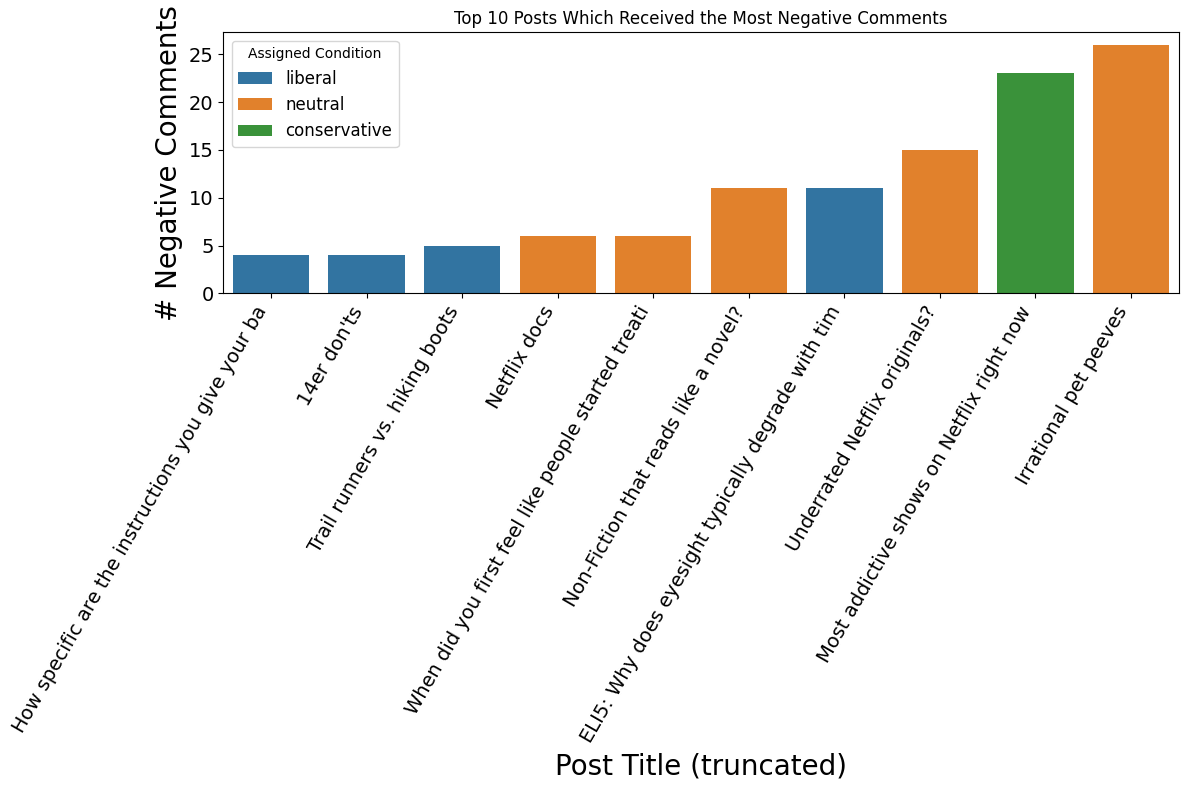

In [121]:
plt.figure(figsize=(12, 8))
sns.barplot(data=exp_by_post.filter(pl.col("title") != "[ Removed by moderator ]").sort("count_negative").tail(10), 
    x="title_short", y="count_negative", hue="label")
plt.xlabel("Post Title (truncated)", fontsize=20)
plt.xticks(rotation=60, ha="right", fontsize=14)
plt.ylabel("# Negative Comments", fontsize=20)
plt.yticks(fontsize=14)
plt.legend(title="Assigned Condition", fontsize=12)
plt.title("Top 10 Posts Which Received the Most Negative Comments")
plt.tight_layout()
plt.show()

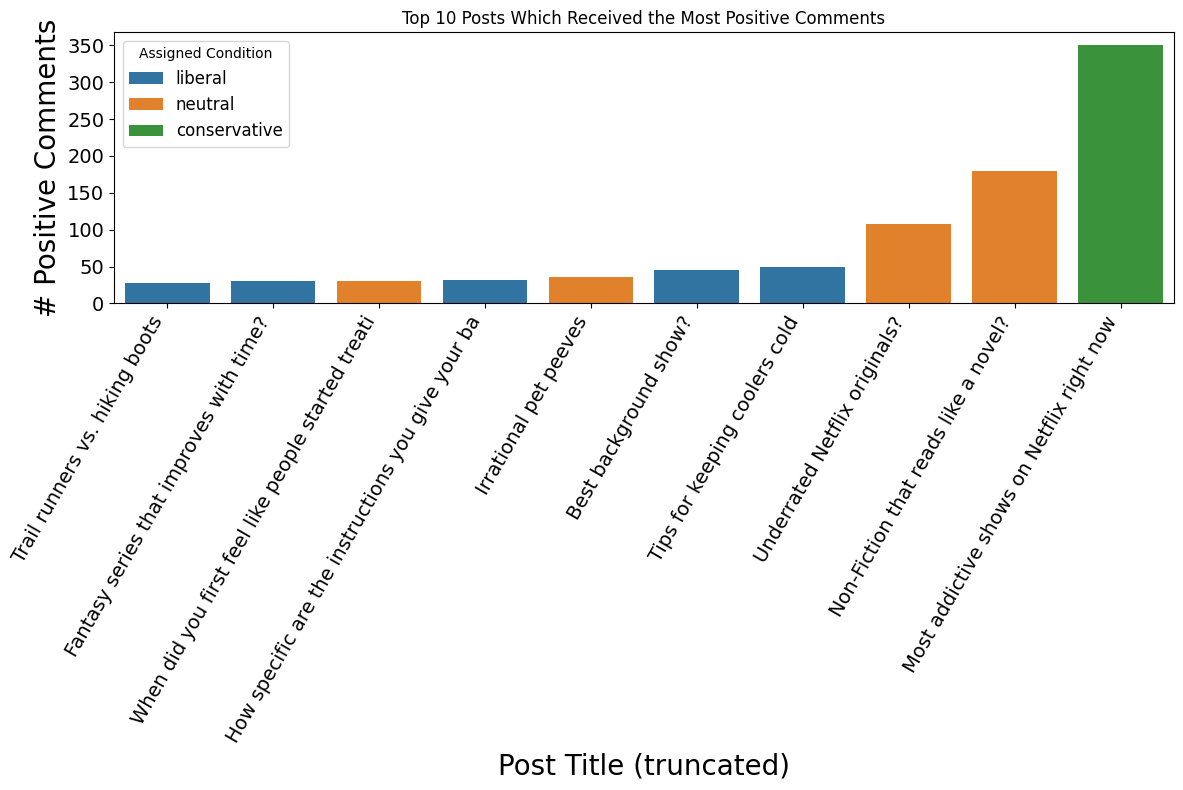

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(data=exp_by_post.filter(pl.col("title") != "[ Removed by moderator ]").sort("count_positive").tail(10), 
    x="title_short", y="count_positive", hue="label")
plt.xlabel("Post Title (truncated)", fontsize=20)
plt.xticks(rotation=60, ha="right", fontsize=14)
plt.ylabel("# Positive Comments", fontsize=20)
plt.yticks(fontsize=14)
plt.legend(title="Assigned Condition", fontsize=12)
plt.title("Top 10 Posts Which Received the Most Positive Comments")
plt.tight_layout()
plt.show()

In [93]:
exp_by_post.group_by(pl.col("label")).median()

label,id,negative,positive,num_replies,title,title_short,subreddit,post_text,count_negative,count_neutral,count_positive
str,str,f64,f64,f64,str,str,str,str,f64,f64,f64
"""liberal""",null,0.177225,0.281104,7.5,null,null,null,null,1.0,4.0,2.0
"""neutral""",null,0.174385,0.196979,9.5,null,null,null,null,1.0,5.5,1.0
"""conservative""",null,0.130135,0.201054,4.0,null,null,null,null,0.0,2.0,1.0


/Users/paulterrasi/Documents/Political-Signaling-Sentiment-Analysis/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 6.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


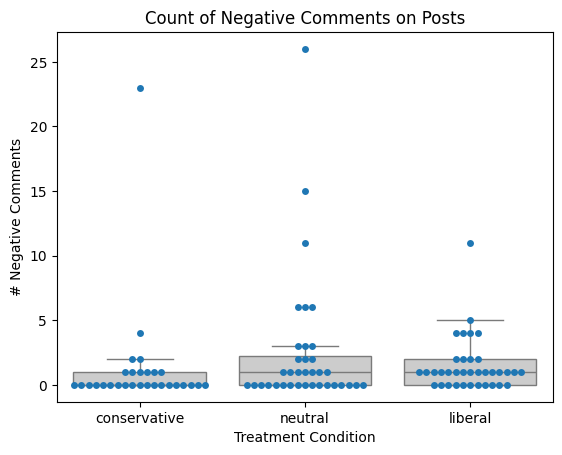

In [ ]:
sns.boxplot(data=exp_by_post, x="label", y="count_negative", color=".8", showfliers=False)
sns.swarmplot(data=exp_by_post, x="label", y="count_negative")
plt.title("Count of Negative Comments on Posts")
plt.ylabel("# Negative Comments")
plt.xlabel("Treatment Condition")
plt.show()

/Users/paulterrasi/Documents/Political-Signaling-Sentiment-Analysis/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 13.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/paulterrasi/Documents/Political-Signaling-Sentiment-Analysis/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 22.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/paulterrasi/Documents/Political-Signaling-Sentiment-Analysis/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 5.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/paulterrasi/Documents/Political-Signaling-Sentiment-Analysis/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 6.9%

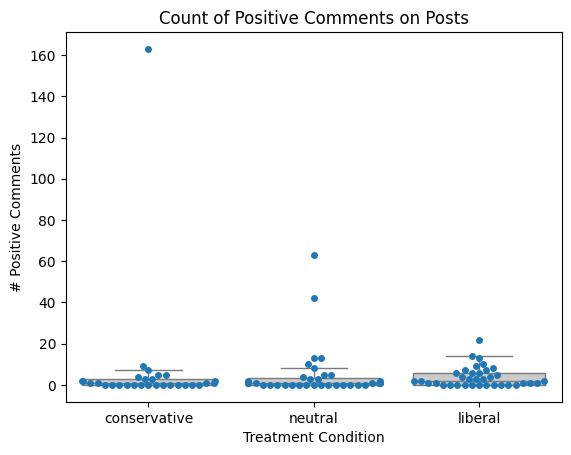

In [109]:
sns.boxplot(data=exp_by_post, x="label", y="count_positive", color=".8", showfliers=False)
sns.swarmplot(data=exp_by_post, x="label", y="count_positive")
plt.title("Count of Positive Comments on Posts")
plt.ylabel("# Positive Comments")
plt.xlabel("Treatment Condition")
plt.show()

In [105]:
exp_no_outlier = exp.filter(pl.col("id") != "1rzj66f")

Text(0.5, 0, 'Experiment Condition')

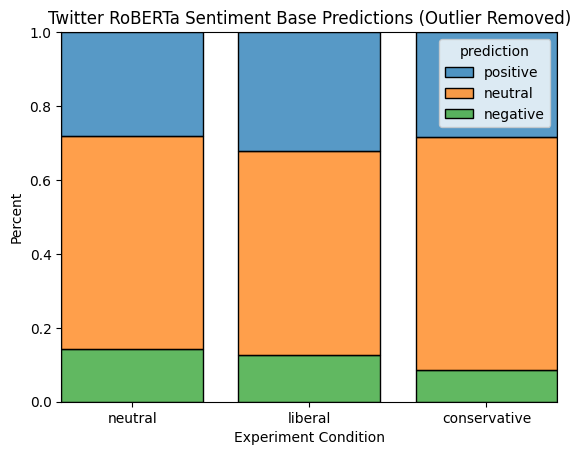

In [107]:
ax = sns.histplot(
    data=exp_no_outlier,
    x="label", hue="prediction",
    hue_order=["positive", "neutral", "negative"],
    multiple="fill", stat="percent",
    discrete=True, shrink=.8
)
ax.set_title("Twitter RoBERTa Sentiment Base Predictions (Outlier Removed)")
ax.set_xlabel("Experiment Condition")

In [126]:
exp.write_csv(here("data/sentiment.csv"))